# CHI-SQUARE

In [1]:
import pandas as pd
import numpy as np

In [4]:
titanic = pd.read_csv('./Titanic-Dataset.csv')[['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Survived']]
titanic.head()

,Pclass,Sex,SibSp,Parch,Embarked,Survived
0,3,male,1,0,S,0
1,1,female,1,0,C,1
2,3,female,0,0,S,1
3,1,female,1,0,S,1
4,3,male,0,0,S,0


In [5]:
ct = pd.crosstab(titanic['Survived'], titanic['Sex'])
ct

Sex,female,male
Survived,,
0,81,468
1,233,109


In [7]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-Square Statistic :", chi2)
print("P-value              :", p)
print("Degrees of Freedom   :", dof)
print("Expected Frequencies :")
print(expected)

Chi-Square Statistic : 260.71702016732104
P-value              : 1.1973570627755645e-58
Degrees of Freedom   : 1
Expected Frequencies :
[[193.47474747 355.52525253]
 [120.52525253 221.47474747]]


In [8]:
score = []

for feat in titanic.columns[:-1]:
    
    ct  = pd.crosstab(titanic['Survived'], titanic[feat])

    p_val = chi2_contingency(ct)[1]
    score.append(p_val)

<Axes: >

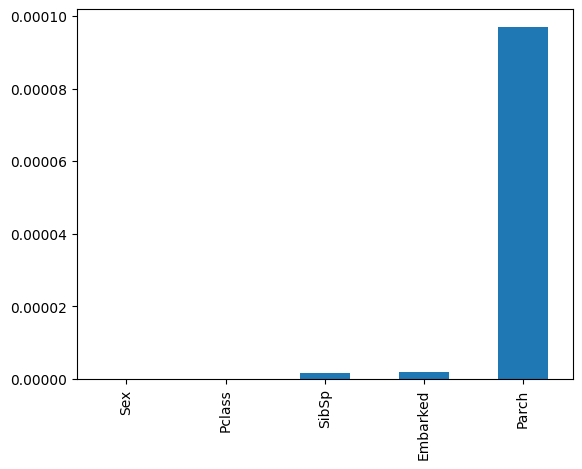

In [9]:
pd.Series(score, index = titanic.columns[:-1]).sort_values(ascending=True).plot(kind= 'bar')